<a href="https://colab.research.google.com/github/vkekd25/Project_Electronic_Commerce/blob/main/E_commerce_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install category_encoders

In [2]:
from google.colab import files
uploaded = files.upload() #내드라이브에 csv파일 불러오기

Saving shipping.csv to shipping (2).csv


# **제품 배송 시간에 맟춰 배송되나요? 전자상거래 고객의 요구에 부응하기위해**

In [3]:
#https://www.kaggle.com/datasets/prachi13/customer-analytics 해당 케글 사이트
import io
import pandas as pd
df = pd.read_csv(io.BytesIO(uploaded['shipping.csv'])) #data.csv불러오기
df.head(3)

df.rename(columns = {'Reached.on.Time_Y.N' : 'Reached_on_Time_YN'}, inplace = True) #편의를 위해 열이름 변경(데이터 전처리)!

In [4]:
#!pip install pandas-profiling==3.1.0 #pandas-profiling 3.1.0 설치

In [5]:
# from pandas_profiling import ProfileReport
# profile = ProfileReport(df, minimal=True).to_notebook_iframe()

Profile 내에서는 데이터에 대한 특이점은 없음

In [6]:
df.shape # 행 10999 열 12개

(10999, 12)

**콘텐츠**
모델 구축에 사용된 데이터 세트에는 12개의 변수에 대한 10999개의 관찰이 포함되었습니다.
데이터에는 다음 정보가 포함됩니다.

**ID**: 고객의 ID 번호입니다.   
**창고** 블록: 회사는 A,B,C,D,E와 같은 블록으로 구분된 큰 창고를 가지고 있습니다.   
**배송방법**: 회사는 선박, 항공, 육로 등 다양한 방법으로 제품을 배송합니다.   
**고객상담전화** : 배송조회 문의에서 걸려온 전화수입니다.   
**고객 평가**: 회사는 모든 고객으로부터 평가했습니다. 1이 가장 낮음(최악), 5가 가장 높음(최상)입니다.   
**제품 비용** : 제품 비용(미국 달러).   
**이전 구매**: 이전 구매 수.   
**제품 중요도**: 회사는 제품을 낮음, 중간, 높음과 같은 다양한 매개변수로 분류했습니다.   
**성별**: 남성과 여성.   
**할인 제공**: 특정 제품에 대해 제공되는 할인.   
**무게(g)**: 무게(g)입니다.   
**정시 도달**: 목표 변수로, 1은 제품이 정시에 도달하지 않았음을 나타내고 0은 정시에 도달했음을 나타냅니다.

#**문제정의**
#**어떤 조건들이 상품들을 제 시간에 도착하는지 안하는지?**

In [7]:
df.head(3)

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached_on_Time_YN
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10999 entries, 0 to 10998
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   ID                   10999 non-null  int64 
 1   Warehouse_block      10999 non-null  object
 2   Mode_of_Shipment     10999 non-null  object
 3   Customer_care_calls  10999 non-null  int64 
 4   Customer_rating      10999 non-null  int64 
 5   Cost_of_the_Product  10999 non-null  int64 
 6   Prior_purchases      10999 non-null  int64 
 7   Product_importance   10999 non-null  object
 8   Gender               10999 non-null  object
 9   Discount_offered     10999 non-null  int64 
 10  Weight_in_gms        10999 non-null  int64 
 11  Reached_on_Time_YN   10999 non-null  int64 
dtypes: int64(8), object(4)
memory usage: 1.0+ MB


In [9]:
df.isnull().sum() # 결측치 제로! Good!

ID                     0
Warehouse_block        0
Mode_of_Shipment       0
Customer_care_calls    0
Customer_rating        0
Cost_of_the_Product    0
Prior_purchases        0
Product_importance     0
Gender                 0
Discount_offered       0
Weight_in_gms          0
Reached_on_Time_YN     0
dtype: int64

In [10]:
df.duplicated(subset = ['ID']).sum() # 중복된 ID 없는거 확인!

0

#**상관계수에 대한 Heatmap**

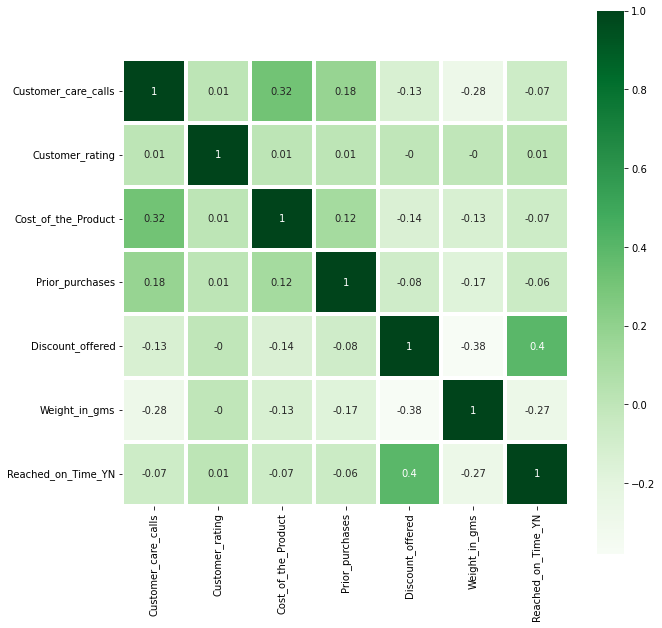

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

%matplotlib inline  
#matplot 그래프가 안나올시
plt.figure(figsize = (10, 10))
sns.heatmap(round(df[['Customer_care_calls', 'Customer_rating', 'Cost_of_the_Product','Prior_purchases', 'Product_importance',
                'Discount_offered', 'Weight_in_gms','Reached_on_Time_YN']].corr(),2),square = True, cmap = 'Greens', annot = True,
                linewidth=3, linecolor='white');
plt.show()

In [12]:
df.corr()['Reached_on_Time_YN'].sort_values()

ID                    -0.411822
Weight_in_gms         -0.268793
Cost_of_the_Product   -0.073587
Customer_care_calls   -0.067126
Prior_purchases       -0.055515
Customer_rating        0.013119
Discount_offered       0.397108
Reached_on_Time_YN     1.000000
Name: Reached_on_Time_YN, dtype: float64

#**상관계수로 봤을때**   
**타겟과 특성간의 관계**  

Reached.on.Time_YN는 Weight_in_gm와 Discount_offered  

**특성들간의 관계**

Customer_care_calls는 Cost_of_the_Product와 Weight_in_gms   
Discount_offered는 Weight_in_gms   
밀접한 관계가 있을것으로 보입니다.

**1. 상품의 무게에 따라 상품이 제때 도착하는지 안하는지?**  
**2. 할인쿠폰을 많이 받은 고객이 상품을 제때 받을수 있는지 없는지?**  
**3. 고객상담전화 수와 상품의 가격과 무게에 영향을주는지?**  
**4. 할인쿠폰을 사용한 상품이 상품 무게와 관련이 있는지?**

In [13]:
df.head(3)

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached_on_Time_YN
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1


In [14]:
from category_encoders import OrdinalEncoder

enc = OrdinalEncoder(cols = ['Mode_of_Shipment', 'Product_importance', 'Gender'])

df_F = df[df['Warehouse_block'] == 'F'].copy()
df_enc = df.copy()
df_enc = enc.fit_transform(df_enc)
df_enc.head(3)

/usr/local/lib/python3.7/dist-packages/statsmodels/tools/_testing.py:19: FutureWarning: pandas.util.testing is deprecated. Use the functions in the public API at pandas.testing instead.
  import pandas.util.testing as tm


,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached_on_Time_YN
0,1,D,1,4,2,177,3,1,1,44,1233,1
1,2,F,1,4,5,216,2,1,2,59,3088,1
2,3,A,1,2,2,183,4,1,2,48,3374,1


In [15]:
df.Warehouse_block.value_counts() #F=3666은 아마 E =  1833 결측된듯하다. 모든 블락의 count가 같기때문에 분석에 무의미하다.

F    3666
D    1834
A    1833
B    1833
C    1833
Name: Warehouse_block, dtype: int64

#**'Warehouse_block' E,F 결측치**

In [16]:
import pandas as pd
from sklearn.cluster import KMeans 
from sklearn.preprocessing import StandardScaler
import numpy as np

df_EF = df_enc[df_enc['Warehouse_block'] == 'F']
scaler = StandardScaler()
Z = scaler.fit_transform(df_EF.iloc[:,[2, 3, 4, 5, 6, 7, 8, 9, 10]])
column = df_EF.iloc[:,[2, 3, 4, 5, 6, 7, 8, 9, 10]].columns
df1 = pd.DataFrame(Z, columns = column)
kmeans = KMeans(n_clusters = 2, random_state = 42)
kmeans.fit(df_EF.iloc[:,[2, 3, 4, 5, 6, 7,8, 9, 10]])
label_new = kmeans.labels_
df_F['Warehouse_block_new'] = label_new
warehouse_index = df[df['Warehouse_block'] == 'F'].index
df = df.drop(warehouse_index)

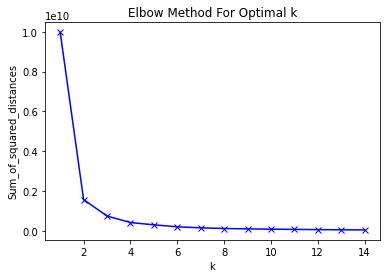

In [17]:
sum_of_squared_distances = []
K = range(1, 15)
for k in K:
    km = KMeans(n_clusters = k)
    km = km.fit(df_EF.iloc[:,[2, 3, 4, 5, 6, 7,8, 9, 10]])
    sum_of_squared_distances.append(km.inertia_)

plt.plot(K, sum_of_squared_distances, 'bx-')
plt.xlabel('k')
plt.ylabel('Sum_of_squared_distances')
plt.title('Elbow Method For Optimal k')
plt.show()

In [18]:
df_enc

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached_on_Time_YN
0,1,D,1,4,2,177,3,1,1,44,1233,1
1,2,F,1,4,5,216,2,1,2,59,3088,1
2,3,A,1,2,2,183,4,1,2,48,3374,1
3,4,B,1,3,3,176,4,2,2,10,1177,1
4,5,C,1,2,2,184,3,2,1,46,2484,1
...,...,...,...,...,...,...,...,...,...,...,...,...
10994,10995,A,2,4,1,252,5,2,1,1,1538,1
10995,10996,B,2,4,1,232,5,2,1,6,1247,0
10996,10997,C,2,5,4,242,5,1,1,4,1155,0
10997,10998,F,2,5,2,223,6,2,2,2,1210,0


In [19]:
def toStr(x):
  x = str(x)
  if x == '0':
    return x.replace('0', 'E')
  if x == '1':
    return x.replace('1', 'F')

In [20]:
df_F['Warehouse_block_new'] = df_F.Warehouse_block_new.apply(toStr)
df_F = df_F.drop('Warehouse_block', axis = 1)
df_F = df_F[['ID', 'Warehouse_block_new','Mode_of_Shipment', 'Customer_care_calls', 'Customer_rating',
       'Cost_of_the_Product', 'Prior_purchases', 'Product_importance',
       'Gender', 'Discount_offered', 'Weight_in_gms', 'Reached_on_Time_YN']]

df_F = df_F.rename(columns={'Warehouse_block_new':'Warehouse_block'})

df = pd.concat([df, df_F])
df = df.reset_index()
df = df.drop('index', axis = 1)

In [21]:
df['Warehouse_block'].value_counts() # E = 2193, F = 1473개 분류!

E    2193
D    1834
A    1833
B    1833
C    1833
F    1473
Name: Warehouse_block, dtype: int64

#**각 Features(범위가 큰 수치형 제외)의 카테고리별 Count수**

In [22]:
df.head(3)

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached_on_Time_YN
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,3,A,Flight,2,2,183,4,low,M,48,3374,1
2,4,B,Flight,3,3,176,4,medium,M,10,1177,1


In [23]:
df.columns

Index(['ID', 'Warehouse_block', 'Mode_of_Shipment', 'Customer_care_calls',
       'Customer_rating', 'Cost_of_the_Product', 'Prior_purchases',
       'Product_importance', 'Gender', 'Discount_offered', 'Weight_in_gms',
       'Reached_on_Time_YN'],
      dtype='object')

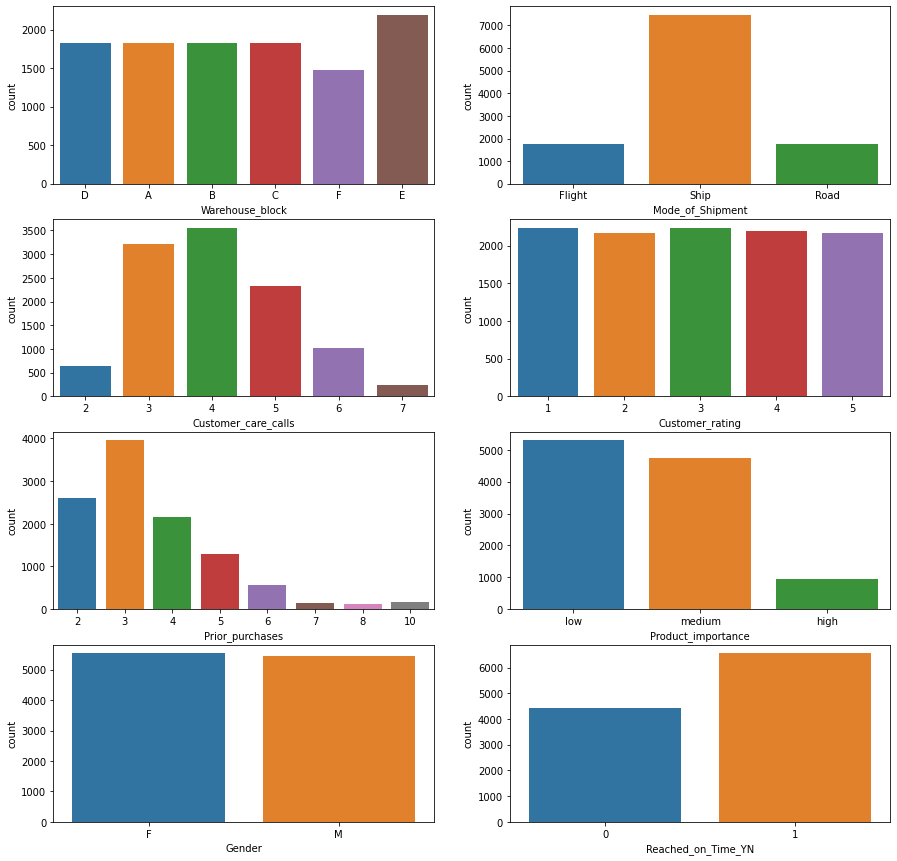

In [24]:
features = ['Warehouse_block', 'Mode_of_Shipment', 'Customer_care_calls',
       'Customer_rating', 'Prior_purchases',
       'Product_importance', 'Gender', 'Reached_on_Time_YN']
plt.figure(figsize = (15, 15))
k = 1

for i in range(len(features)):
  if k <= 8:
    ax = plt.subplot(4, 2, k)
    sns.countplot(x = features[i], data = df)
    k += 1
plt.show()

In [25]:
df.columns

Index(['ID', 'Warehouse_block', 'Mode_of_Shipment', 'Customer_care_calls',
       'Customer_rating', 'Cost_of_the_Product', 'Prior_purchases',
       'Product_importance', 'Gender', 'Discount_offered', 'Weight_in_gms',
       'Reached_on_Time_YN'],
      dtype='object')

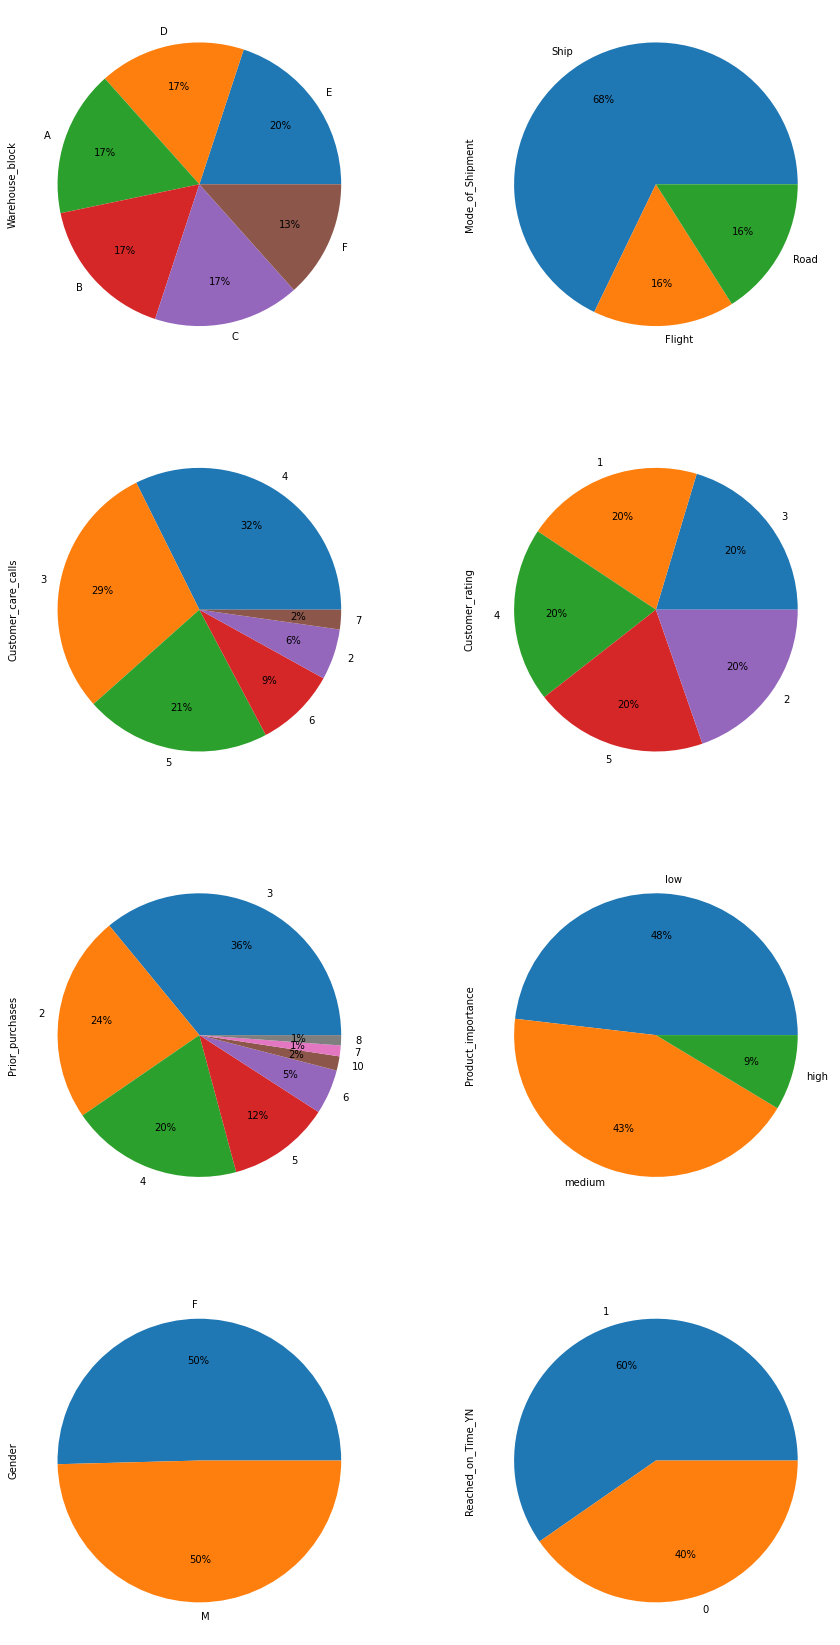

In [26]:
features = ['Warehouse_block', 'Mode_of_Shipment', 'Customer_care_calls',
       'Customer_rating', 'Prior_purchases',
       'Product_importance', 'Gender', 'Reached_on_Time_YN']
plt.figure(figsize = (15, 30))
k = 1

for i in features:
  if k <= 8:
    ax = plt.subplot(4, 2, k)
    df[i].value_counts().plot(kind = 'pie', autopct = '%1.0f%%', 
                                        pctdistance=0.7);
    k += 1
plt.show()

#**각 Features(수치형) 분포 Count수**

In [27]:
df.columns

Index(['ID', 'Warehouse_block', 'Mode_of_Shipment', 'Customer_care_calls',
       'Customer_rating', 'Cost_of_the_Product', 'Prior_purchases',
       'Product_importance', 'Gender', 'Discount_offered', 'Weight_in_gms',
       'Reached_on_Time_YN'],
      dtype='object')

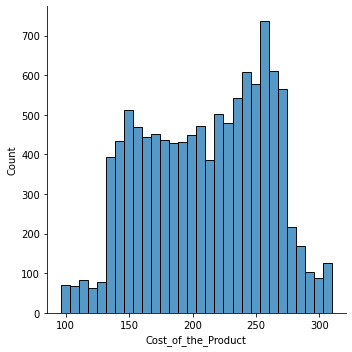

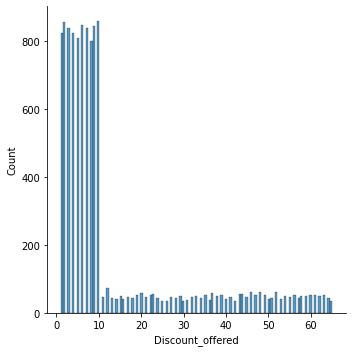

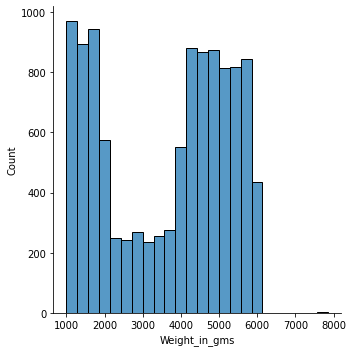

In [28]:
features = ['Cost_of_the_Product', 'Discount_offered', 'Weight_in_gms']
for i in features:
    sns.displot(data = df, x = i)

#**각 Feature들간의 관계**

In [29]:
# Customer_care_calls는 Cost_of_the_Product와 Weight_in_gms
# Discount_offered는 Weight_in_gms
df.head(3)

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached_on_Time_YN
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,3,A,Flight,2,2,183,4,low,M,48,3374,1
2,4,B,Flight,3,3,176,4,medium,M,10,1177,1


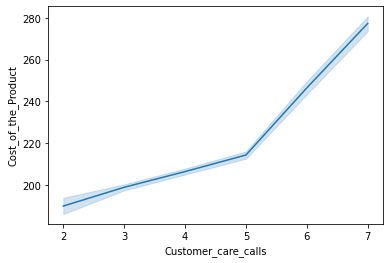

In [30]:
sns.lineplot(data = df, x = 'Customer_care_calls', y = 'Cost_of_the_Product');

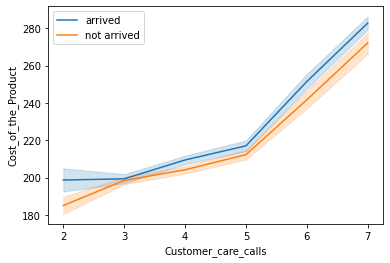

In [31]:
ax = sns.lineplot(data = df, x = 'Customer_care_calls', y = 'Cost_of_the_Product',hue = 'Reached_on_Time_YN')
ax.legend(['arrived', 'not arrived']);

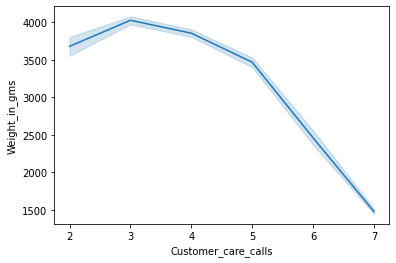

In [32]:
sns.lineplot(data = df, x = 'Customer_care_calls', y = 'Weight_in_gms');

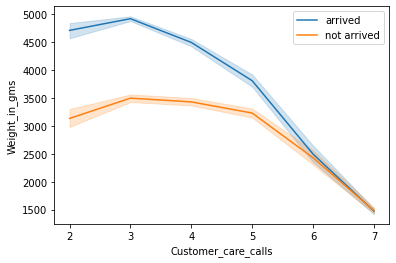

In [33]:
ax = sns.lineplot(data = df, x = 'Customer_care_calls', y = 'Weight_in_gms', hue = 'Reached_on_Time_YN');
ax.legend(['arrived', 'not arrived']);

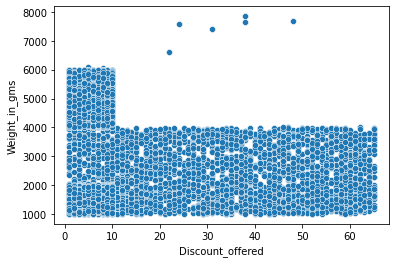

In [34]:
sns.scatterplot(x = 'Discount_offered', y = 'Weight_in_gms',  data = df);

**할인 쿠폰을 적게 받은 상품들이 상대적으로 무게가 높은분포를 띄고있다.**

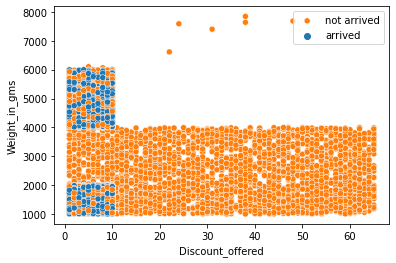

In [35]:
ax = sns.scatterplot(x = 'Discount_offered', y = 'Weight_in_gms',  data = df, hue = 'Reached_on_Time_YN');
ax.legend(['not arrived', 'arrived']);

**이그래프를 보면 제시간에 도착하지않은 상품들은 대부분 할인쿠폰을 적게 받았던 것으로 보인다.**

#**Target('Reached_on_Time_YN') 과 각 범주형 데이터 특성 관계**

In [36]:
def feature_count(df, target, feature):
  Y = df[df[target] ==1][feature].value_counts()
  N = df[df[target] ==0][feature].value_counts()

  sns.set(rc={'figure.figsize':(15,8)})
  df_new = pd.concat([Y, N], axis = 1)
  legend_labels=['not arrived','arrived']
  ax = df_new.plot(kind = 'bar', color = ['red', 'blue'])
  ax.legend(legend_labels, loc = 'upper right');
  plt.xticks(rotation = 0)
  plt.show()

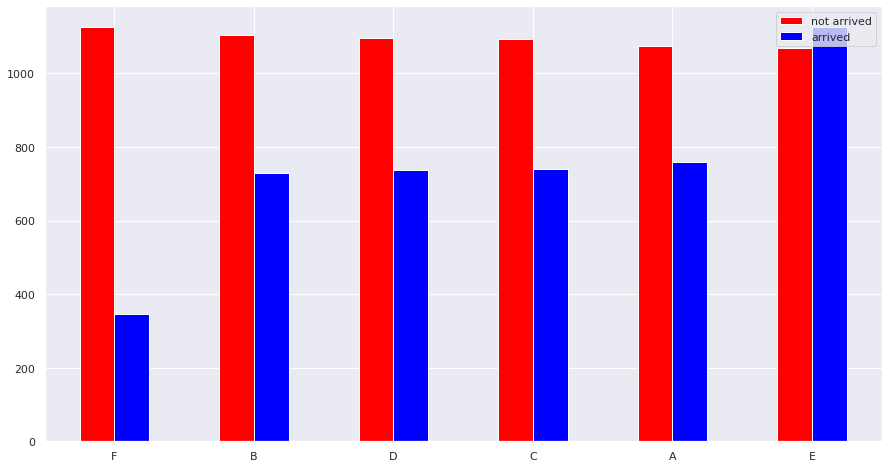

In [37]:
feature_count(df, 'Reached_on_Time_YN', 'Warehouse_block')

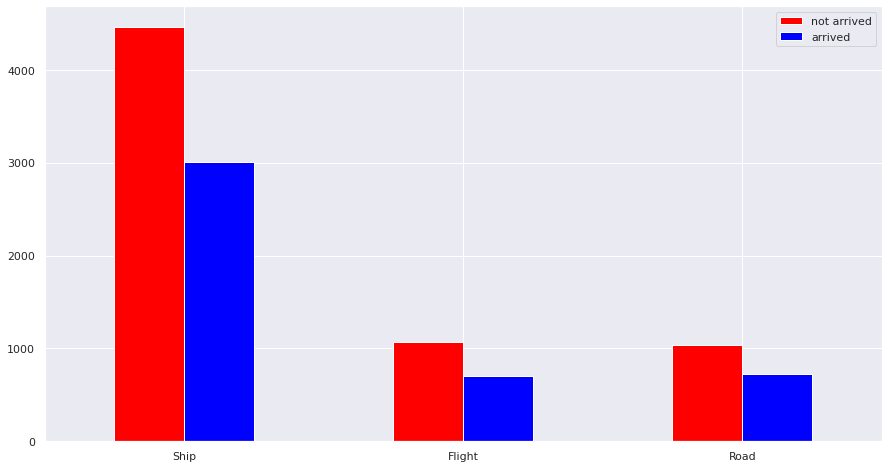

In [38]:
feature_count(df, 'Reached_on_Time_YN', 'Mode_of_Shipment')

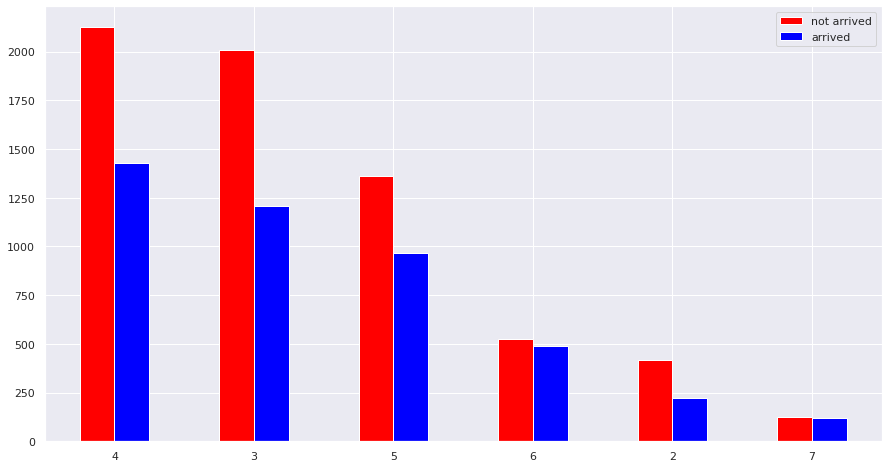

In [39]:
feature_count(df, 'Reached_on_Time_YN', 'Customer_care_calls')

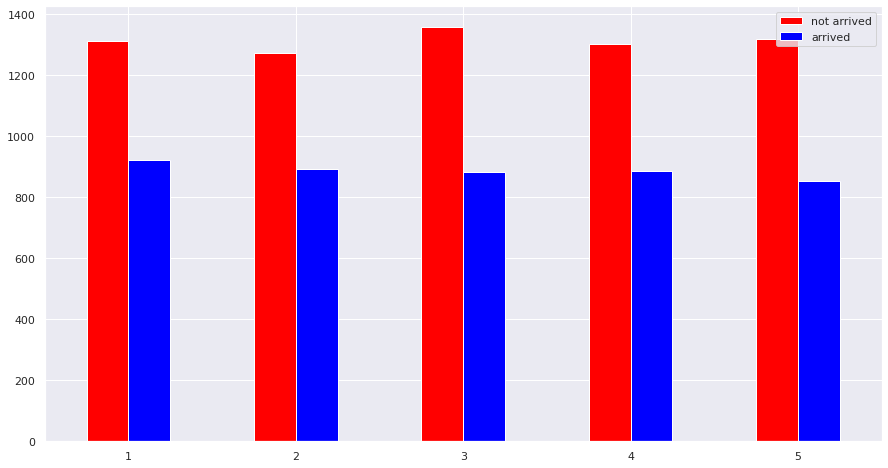

In [40]:
feature_count(df, 'Reached_on_Time_YN', 'Customer_rating')

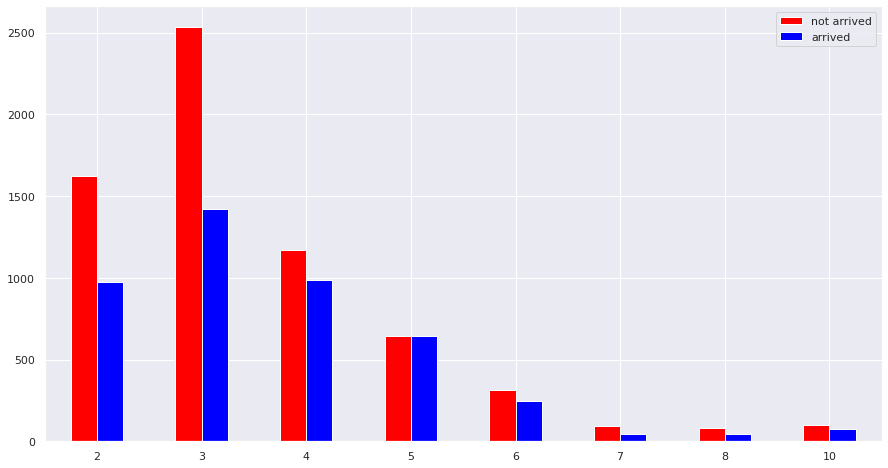

In [41]:
feature_count(df, 'Reached_on_Time_YN', 'Prior_purchases')

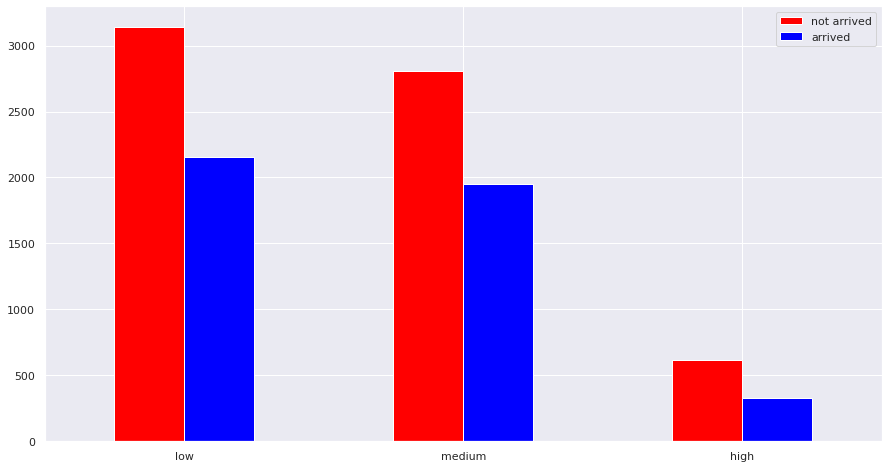

In [42]:
feature_count(df, 'Reached_on_Time_YN', 'Product_importance')

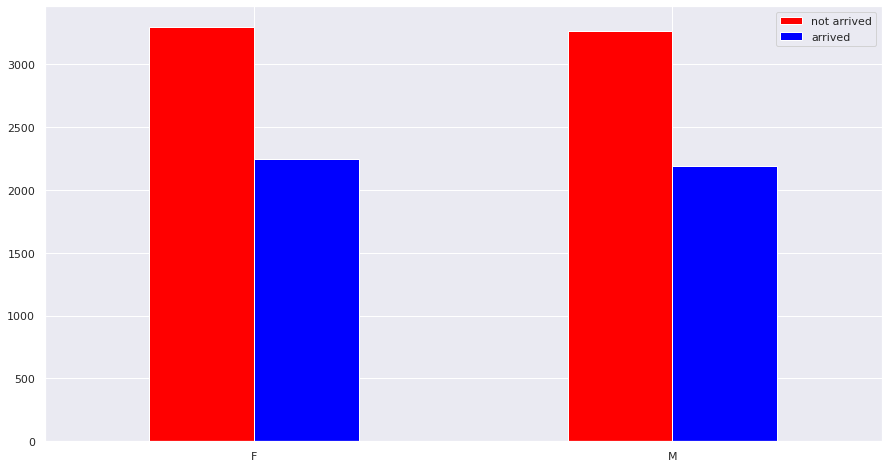

In [43]:
feature_count(df, 'Reached_on_Time_YN', 'Gender')

#**Target('Reached_on_Time_YN') 과 각 수치형 데이터 특성 관계**

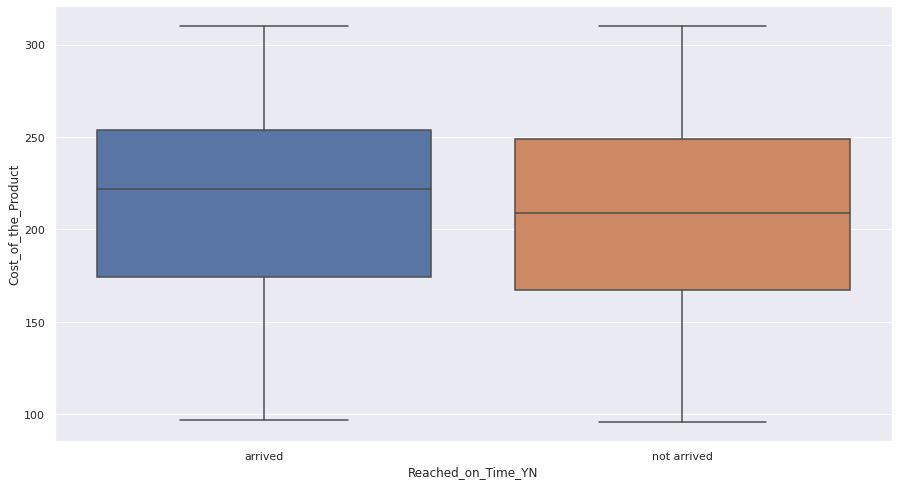

In [44]:
ax = sns.boxplot(x = 'Reached_on_Time_YN', y = 'Cost_of_the_Product', data = df)
ax.set_xticklabels(['arrived', 'not arrived'] );

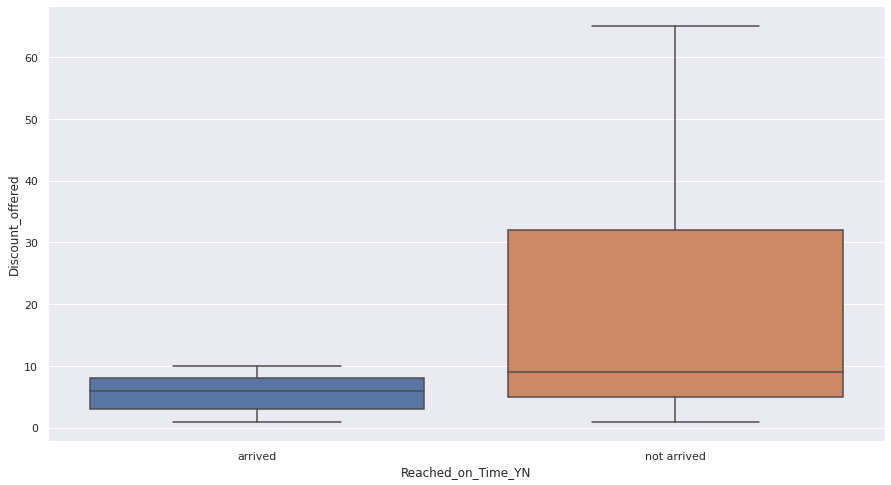

In [45]:
ax = sns.boxplot(x = 'Reached_on_Time_YN', y = 'Discount_offered', data = df);
ax.set_xticklabels(['arrived', 'not arrived'] );

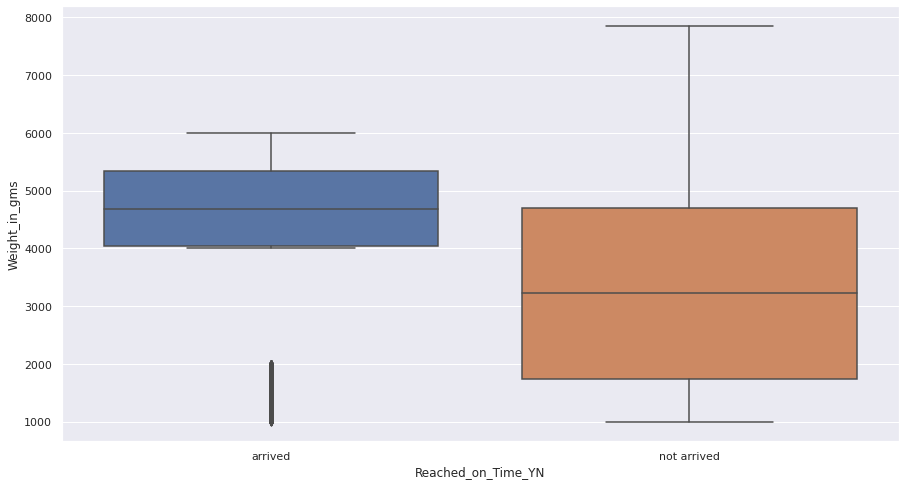

In [46]:
ax = sns.boxplot(x = 'Reached_on_Time_YN', y = 'Weight_in_gms', data = df);
ax.set_xticklabels(['arrived', 'not arrived'] );

#1. 상품의 무게에 따라 상품이 제때 도착하는지 안하는지?
**Ans) 상품의 무게가 많이 나갈수록 상품이 제때 잘도착하는것으로 나온다.**


#2. 할인쿠폰을 많이 받은 고객이 상품을 제때 받을수 있는지 없는지?
**Ans) 할인쿠폰을 많이 받은 사람일수록 상품을 제때 받지 못한다.** 


#3. 고객상담전화 수와 상품의 가격과 무게에 영향을주는지?
**Ans) 고객상담전화 수가 많을수록 상품의 무게가 적게 나가고 상품의 가격은 높았다.** 


#4. 할인쿠폰을 사용한 상품이 상품 무게와 관련이 있는지?
**Ans) 할인쿠폰을 적게 받은 사람일수록 상품의 무게가 많이 나간다.**


#**모델학습**

In [47]:
df['Reached_on_Time_YN'].value_counts(normalize = True)

1    0.596691
0    0.403309
Name: Reached_on_Time_YN, dtype: float64

**타겟 특성의 Class비율은 1: 0.5996 / 0: 0.403  
최빈값의 타겟 Class 비율이 70% 안넘으므로 정확도(Accuracy) 위주로 모델평가를 해보겠습니다.**


In [48]:
from sklearn.model_selection import train_test_split

df = df.drop('ID', axis = 1)
target = 'Reached_on_Time_YN'
X = df.drop(columns = target)
y = df[target]
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.3, train_size = 0.7, random_state=42)
X_train.shape, X_val.shape, y_train.shape, y_val.shape

((7699, 10), (3300, 10), (7699,), (3300,))

In [49]:
X_train.head(3)

,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms
9957,E,Ship,3,1,202,3,medium,F,7,5818
1507,C,Ship,3,2,208,4,medium,M,52,2900
6382,B,Road,4,4,204,3,low,F,9,4757


#**기준모델**

In [50]:
from sklearn.metrics import accuracy_score

y_train.value_counts(normalize = True)
major = y_train.mode()[0]
y_pred = [major] * len(y_train)
print("정확도 for train", accuracy_score(y_train, y_pred))

정확도 for train 0.5956617742563969


#**LogisticRegression**

In [51]:
from category_encoders import OneHotEncoder
from sklearn.feature_selection import f_regression, SelectKBest
from sklearn.model_selection import cross_val_score
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
np.seterr(divide='ignore', invalid='ignore')

column = ['Warehouse_block', 'Mode_of_Shipment', 'Customer_care_calls','Customer_rating','Prior_purchases','Product_importance', 'Gender']
pipe = make_pipeline(
    OneHotEncoder(cols = column,use_cat_names = True), 
    SimpleImputer(strategy='mean'), 
    LogisticRegression(random_state = 42)
)

k = 5

scores = cross_val_score(pipe, X_train, y_train, cv=k, 
                         scoring='accuracy')
print(f'정확도 for {k}-folds cv:', scores.mean())

정확도 for 5-folds cv: 0.6334621064445626


##**Decision Tree**

In [52]:
from sklearn.tree import DecisionTreeClassifier

pipe1 = make_pipeline(
    OrdinalEncoder(cols = column), 
    SimpleImputer(), 
    DecisionTreeClassifier(random_state = 42)
)

scores = cross_val_score(pipe1, X_train, y_train, cv=k, 
                         scoring='accuracy')

print(f'정확도 for {k}-folds:', scores.mean())

정확도 for 5-folds: 0.642813346497557


#**RandomForest**

In [53]:
from sklearn.ensemble import RandomForestClassifier

pipe2 = make_pipeline(
    OrdinalEncoder(cols = column), 
    SimpleImputer(), 
    RandomForestClassifier(random_state = 42)
)

scores = cross_val_score(pipe2, X_train, y_train, cv=k, 
                         scoring='accuracy')

print(f'정확도 for {k}-folds:', scores.mean())

정확도 for 5-folds: 0.6630742681619874


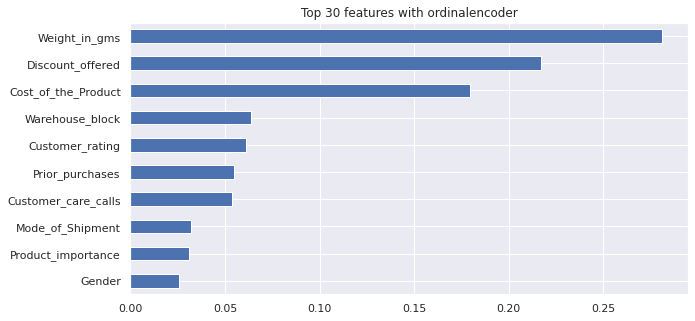

In [86]:
# 특성 중요도(ordinal)
pipe2.fit(X_train, y_train)
rf_ord = pipe2.named_steps['randomforestclassifier']
importances_ord = pd.Series(rf_ord.feature_importances_, X_train.columns)
n=30
plt.figure(figsize=(10,20/4))
plt.title(f'Top {n} features with ordinalencoder')
importances_ord.sort_values()[-n:].plot.barh();

**K-Means Clustering으로 결측치를 채운 'Warehouse_block' drop후 RandomForest 모델링**

In [54]:
df1 = pd.read_csv(io.BytesIO(uploaded['shipping.csv']))
df1.rename(columns = {'Reached.on.Time_Y.N' : 'Reached_on_Time_YN'}, inplace = True)
df1 = df1.drop(['ID','Warehouse_block'], axis = 1)
target = 'Reached_on_Time_YN'
X1 = df1.drop(columns = target)
y1 = df1[target]
X1_train, X1_val, y1_train, y1_val = train_test_split(X1, y1, test_size=0.3, train_size = 0.7, random_state=42)
X1_train.shape, X1_val.shape, y1_train.shape, y1_val.shape

((7699, 9), (3300, 9), (7699,), (3300,))

In [55]:
from sklearn.ensemble import RandomForestClassifier

column1 = ['Mode_of_Shipment', 'Customer_care_calls','Customer_rating','Prior_purchases','Product_importance', 'Gender']
pipe3 = make_pipeline(
    OrdinalEncoder(cols = column1), 
    SimpleImputer(), 
    RandomForestClassifier(random_state = 42)
)

scores = cross_val_score(pipe3, X1_train, y1_train, cv=k, 
                         scoring='accuracy')

print(f'정확도 for {k}-folds:', scores.mean())

정확도 for 5-folds: 0.6578780284043442


#**종류별 Imputer**

**Simple Imputer  
Iterative Imputer  
KNN Imputer**

**Iterative Imputer**

In [56]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer


pipe4 = make_pipeline(
    OrdinalEncoder(cols = column), 
    IterativeImputer(), 
    RandomForestClassifier(random_state = 42)
)

scores = cross_val_score(pipe4, X_train, y_train, cv=k, 
                         scoring='accuracy')

print(f'정확도 for {k}-folds:', scores.mean())

정확도 for 5-folds: 0.6630742681619874


**KNNImputer**

In [57]:
from sklearn.impute import KNNImputer


pipe5 = make_pipeline(
    OrdinalEncoder(cols = column), 
    KNNImputer(), 
    RandomForestClassifier(random_state = 42)
)

scores = cross_val_score(pipe5, X_train, y_train, cv=k, 
                         scoring='accuracy')

print(f'정확도 for {k}-folds:', scores.mean())

정확도 for 5-folds: 0.6630742681619874


**결측치가 없으므로 Imputer를 쓸 의미가 없다.**

#**종류별 Encoder**
**CatBoostEncoder  
GLMMEncoder(일반화 선형 혼합 모델 인코더)  
HelmertEncoder  
JamesSteinEncoder  
TargetEncoder  
BackwardDifferenceEncoder  
BaseNEncoder  
CountEncoder  
HashingEncoder  
HelmertEncoder  
JamesSteinEncoder  
LeaveOneOutEncoder  
MEstimateEncoder  
PolynomialEncoder  
SumEncoder  
WOEEncoder  
QuantileEncoder  
SummaryEncoder** 

**CatBoostEncoder**

In [58]:
from category_encoders import CatBoostEncoder

pipe6 = make_pipeline(
    CatBoostEncoder(), 
    RandomForestClassifier(random_state=42) 
)

scores = cross_val_score(pipe6, X_train, y_train, cv=k, 
                         scoring='accuracy')

print(f'정확도 for {k}-folds:', scores.mean())

scores1 = cross_val_score(pipe6, X_train, y_train, cv=k, 
                         scoring='accuracy')

정확도 for 5-folds: 0.670480578550754


**GLMMEncoder(일반화 선형 혼합 모델 인코더)**

In [59]:
from category_encoders import GLMMEncoder

pipe7 = make_pipeline(
    GLMMEncoder(), 
    RandomForestClassifier(random_state=42) 
)

scores = cross_val_score(pipe7, X_train, y_train, cv=k, 
                         scoring='accuracy')

print(f'정확도 for {k}-folds:', scores.mean())

정확도 for 5-folds: 0.6608674885867869


**HelmertEncoder**

In [60]:
from category_encoders import HelmertEncoder

pipe8 = make_pipeline(
    HelmertEncoder(), 
    RandomForestClassifier(random_state=42) 
)

scores = cross_val_score(pipe8, X_train, y_train, cv=k, 
                         scoring='accuracy')

print(f'정확도 for {k}-folds:', scores.mean())

정확도 for 5-folds: 0.6567093660076117


**JamesSteinEncoder**

In [61]:
from category_encoders import JamesSteinEncoder

pipe9 = make_pipeline(
    JamesSteinEncoder(), 
    RandomForestClassifier(random_state=42) 
)

scores = cross_val_score(pipe9, X_train, y_train, cv=k, 
                         scoring='accuracy')

print(f'정확도 for {k}-folds:', scores.mean())

정확도 for 5-folds: 0.65697054083019


**TargetEncoder**

In [62]:
from category_encoders import TargetEncoder

pipe10 = make_pipeline(
    TargetEncoder(), 
    RandomForestClassifier(random_state=42) 
)

scores = cross_val_score(pipe10, X_train, y_train, cv=k, 
                         scoring='accuracy')

print(f'정확도 for {k}-folds:', scores.mean())

정확도 for 5-folds: 0.65697054083019


**BackwardDifferenceEncoder**

In [63]:
from category_encoders import BackwardDifferenceEncoder

pipe11 = make_pipeline(
    BackwardDifferenceEncoder(), 
    RandomForestClassifier(random_state=42) 
)

scores = cross_val_score(pipe11, X_train, y_train, cv=k, 
                         scoring='accuracy')

print(f'정확도 for {k}-folds:', scores.mean())

정확도 for 5-folds: 0.6567113068867455


**BaseNEncoder**

In [64]:
from category_encoders import BaseNEncoder

pipe12 = make_pipeline(
    BaseNEncoder(), 
    RandomForestClassifier(random_state=42) 
)

scores = cross_val_score(pipe12, X_train, y_train, cv=k, 
                         scoring='accuracy')

print(f'정확도 for {k}-folds:', scores.mean())

정확도 for 5-folds: 0.6548921968220214


**CountEncoder**


In [65]:
from category_encoders import CountEncoder

pipe13 = make_pipeline(
    CountEncoder(), 
    RandomForestClassifier(random_state=42) 
)

scores = cross_val_score(pipe13, X_train, y_train, cv=k, 
                         scoring='accuracy')

print(f'정확도 for {k}-folds:', scores.mean())

정확도 for 5-folds: 0.661516670464039


**HashingEncoder**

In [66]:
from category_encoders import HashingEncoder

pipe14 = make_pipeline(
    HashingEncoder(), 
    RandomForestClassifier(random_state=42) 
)

scores = cross_val_score(pipe14, X_train, y_train, cv=k, 
                         scoring='accuracy')

print(f'정확도 for {k}-folds:', scores.mean())

정확도 for 5-folds: 0.6596985730319064


**LeaveOneOutEncoder**

In [67]:
from category_encoders import LeaveOneOutEncoder

pipe15 = make_pipeline(
    LeaveOneOutEncoder(), 
    RandomForestClassifier(random_state=42) 
)

scores = cross_val_score(pipe15, X_train, y_train, cv=k, 
                         scoring='accuracy')

print(f'정확도 for {k}-folds:', scores.mean())

정확도 for 5-folds: 0.5956617975916221


**MEstimateEncoder**

In [68]:
from category_encoders import MEstimateEncoder

pipe16 = make_pipeline(
    MEstimateEncoder(), 
    RandomForestClassifier(random_state=42) 
)

scores = cross_val_score(pipe16, X_train, y_train, cv=k, 
                         scoring='accuracy')

print(f'정확도 for {k}-folds:', scores.mean())

정확도 for 5-folds: 0.65697054083019


**PolynomialEncoder**

In [69]:
from category_encoders import PolynomialEncoder

pipe17 = make_pipeline(
    PolynomialEncoder(), 
    RandomForestClassifier(random_state=42) 
)

scores = cross_val_score(pipe17, X_train, y_train, cv=k, 
                         scoring='accuracy')

print(f'정확도 for {k}-folds:', scores.mean())

정확도 for 5-folds: 0.6572300279317823


**SumEncoder**

In [70]:
from category_encoders import SumEncoder

pipe18 = make_pipeline(
    SumEncoder(), 
    RandomForestClassifier(random_state=42) 
)

scores = cross_val_score(pipe18, X_train, y_train, cv=k, 
                         scoring='accuracy')

print(f'정확도 for {k}-folds:', scores.mean())

정확도 for 5-folds: 0.6643746571816748


**WOEEncoder**

In [71]:
from category_encoders import WOEEncoder

pipe19 = make_pipeline(
    WOEEncoder(), 
    RandomForestClassifier(random_state=42) 
)

scores = cross_val_score(pipe19, X_train, y_train, cv=k, 
                         scoring='accuracy')

print(f'정확도 for {k}-folds:', scores.mean())

정확도 for 5-folds: 0.65697054083019


**QuantileEncoder**

In [72]:
from category_encoders import QuantileEncoder

pipe20 = make_pipeline(
    QuantileEncoder(), 
    RandomForestClassifier(random_state=42) 
)

scores = cross_val_score(pipe20, X_train, y_train, cv=k, 
                         scoring='accuracy')

print(f'정확도 for {k}-folds:', scores.mean())

정확도 for 5-folds: 0.6624251706707847


**SummaryEncoder**

In [73]:
from category_encoders import SummaryEncoder

pipe21 = make_pipeline(
    QuantileEncoder(), 
    RandomForestClassifier(random_state=42) 
)

scores = cross_val_score(pipe21, X_train, y_train, cv=k, 
                         scoring='accuracy')

print(f'정확도 for {k}-folds:', scores.mean())

정확도 for 5-folds: 0.6624251706707847


**18개 Encoder중 Catboost Encoder가 가장 높게 나옴**

**최종적으로 'Warehouse_Block' 특성 + 최적화된 RandomForest 모델학습**

In [74]:
from category_encoders import CatBoostEncoder
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform
import warnings
warnings.filterwarnings('ignore')

pipe22 = make_pipeline(
    CatBoostEncoder(random_state = 42),  
    RandomForestClassifier(random_state=42, oob_score=True)
)

dists = {
    'randomforestclassifier__n_estimators': randint(100, 500), 
    'randomforestclassifier__max_depth': [5, 10, 13 ,15, 17, 20, 25], 
    'randomforestclassifier__min_samples_leaf' : [1,3,6],
    'randomforestclassifier__max_leaf_nodes' : [300, 600, 1000],
    'randomforestclassifier__max_features': ['sqrt', 'log2', None, 'auto'], # max_features
    'randomforestclassifier__class_weight' : ['balanced', 'balanced_subsample']
}

clf = RandomizedSearchCV(
    pipe22, 
    param_distributions=dists, 
    n_iter=50, 
    cv=3, 
    scoring='accuracy',  
    verbose=1,
    n_jobs=-1
)

clf.fit(X_train, y_train);

Fitting 3 folds for each of 50 candidates, totalling 150 fits


In [75]:
print('최적 하이퍼파라미터: ', clf.best_params_)
print('정확도 : ', clf.best_score_)

최적 하이퍼파라미터:  {'randomforestclassifier__class_weight': 'balanced_subsample', 'randomforestclassifier__max_depth': 5, 'randomforestclassifier__max_features': 'log2', 'randomforestclassifier__max_leaf_nodes': 300, 'randomforestclassifier__min_samples_leaf': 1, 'randomforestclassifier__n_estimators': 239}
정확도 :  0.6851538548657476


#**분류 평가지표**

In [76]:
from sklearn.metrics import classification_report

y_pred = clf.predict(X_val)
print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

           0       0.56      0.98      0.71      1323
           1       0.97      0.49      0.65      1977

    accuracy                           0.69      3300
   macro avg       0.77      0.74      0.68      3300
weighted avg       0.81      0.69      0.68      3300



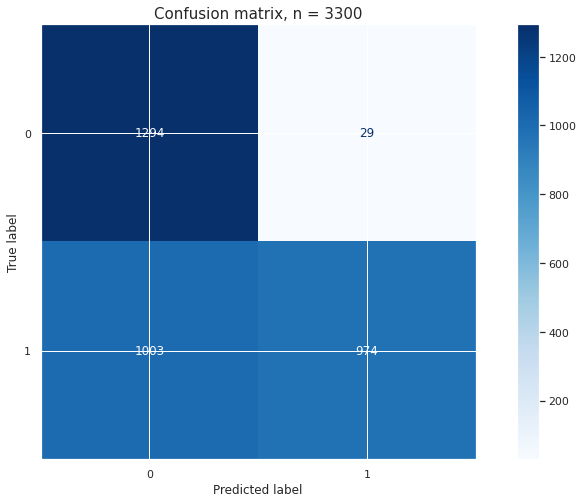

In [77]:
from sklearn.metrics import plot_confusion_matrix

fig, ax = plt.subplots()
pcm = plot_confusion_matrix(clf, X_val, y_val,
                            cmap=plt.cm.Blues,
                            ax=ax)
plt.title(f'Confusion matrix, n = {len(y_val)}', fontsize=15)
plt.show()

**ROC Curve**

In [88]:
from sklearn.metrics import roc_curve

y_pred_proba = clf.predict_proba(X_val)[:, 1]
fpr, tpr, thresholds = roc_curve(y_val, y_pred_proba)

# threshold 최대값의 인덱스, np.argmax()
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]

print('idx:', optimal_idx, ', threshold:', optimal_threshold)

idx: 186 , threshold: 0.5699143318010377


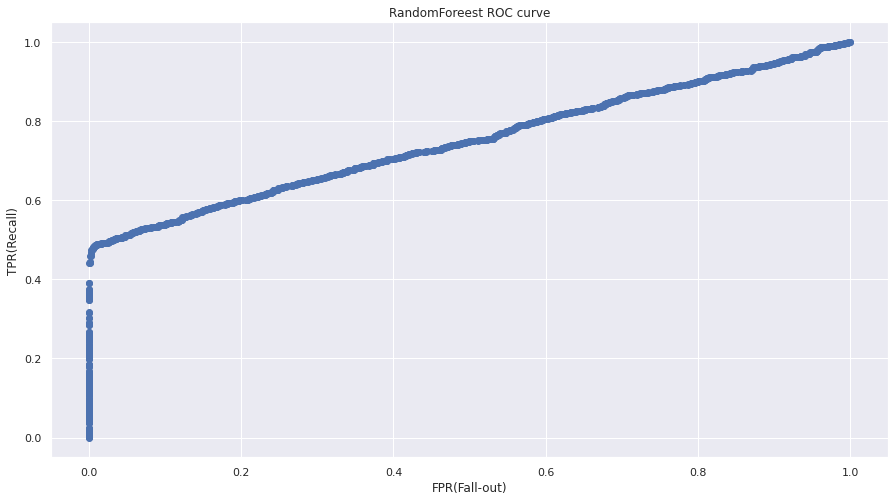

In [92]:
plt.scatter(fpr, tpr)
plt.title('RandomForeest ROC curve')
plt.xlabel('FPR(Fall-out)')
plt.ylabel('TPR(Recall)');

In [90]:
from sklearn.metrics import roc_auc_score
auc_score = roc_auc_score(y_val, y_pred_proba)
auc_score

0.7499991397671866

#**비지니스 관점**
**이 문제에서는 0(상품 도착한 경우)이라고 예측했는데
실제 1(상품 도착하지 않은 경우)인경우가 치명적이다**  
**1(상품이 도착하지 않은 경우)이라고 예측했는데 실제 0(상품이 도착한 경우)는 개이득!**


**재현율 : 아니라고 했는데 맞는 경우의 리스크가 큰 경우  
정밀도 : 맞다고 했는데 아닌경우의 더 리스크가 큰 경우**

**재현율이 중요함**

**->FN가 치명적이다 -> 임계치를 낮춘다 -> FN을 줄인다 -> 재현율을 높이고 정밀도를 낮아진다.**

In [91]:
threshold = 0.4
y_pred_proba = clf.predict_proba(X_val)[:, 1]
y_pred = y_pred_proba > threshold

vc = pd.Series(y_pred).value_counts()
print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

           0       0.57      0.86      0.68      1323
           1       0.85      0.57      0.68      1977

    accuracy                           0.68      3300
   macro avg       0.71      0.71      0.68      3300
weighted avg       0.74      0.68      0.68      3300



**임계치를 0.4로 내렸을때 정확도(Accuracy)는 0.01이 낮아지는것으로 보인다. 하지만 비지니스관점에서 FN이 치면적이므로 정확도 손해를 조금보더라도 임계치를 줄이는것이 합리적이라고 생각합니다.**